#  ACC102 Mini Assignment – Track 1
#  Apple Stock Performance During and After COVID-19: A Data Story for Beginner Investors
# **Author**: Yuxing Zhang
# **Date**: April 2026  
# **Data source**: WRDS CRSP Daily Stock File (accessed live on April 12, 2026)  
# **Track**: 1 – Social Media Data Story

#  1. Problem Definition & Target Audience
# **Analytical problem**:  
# How did the COVID-19 pandemic affect Apple's stock price and returns, and how quickly did it recover? What can beginner investors learn from this pattern? 
# **Target audience**:  
# Beginner investors and business students who want to learn how to use WRDS/CRSP stock data to analyze a company's performance during a major crisis. 
# **Specific questions**:
# - How much did Apple's stock drop at the peak of the pandemic?
# - How long did it take to recover to pre-COVID levels?
# - What does the volatility pattern tell us about market reactions?

#  2. Data Source Declaration
# | Item | Detail |
# |------|--------|
# | Platform | WRDS (Wharton Research Data Services) |
# | Library | CRSP - Daily Stock File (`crsp.dsf`) |
# | Company | Apple Inc. (PERMNO `14593`) |
# | Time period | 2018-01-01 to 2023-12-31 |
# | Variables | `date`, `ret` (daily return), `prc` (price) |
# | Access date | April 12, 2026 |

#  3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wrds import Connection
from datetime import datetime

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported.")

Libraries imported.


#  4. Connect to WRDS and Retrieve Data

In [2]:
# Connect
db = Connection()
print("WRDS connected.")

Enter your WRDS username [章钰瑆]: yuxingzhang24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\章钰瑆\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connected.


In [3]:
# Apple's PERMNO in CRSP
permno_aapl = 14593
start_date = '2018-01-01'
end_date = '2023-12-31'

# Use pd.read_sql instead of db.raw_sql to avoid compatibility issues
query = f"""
SELECT date, permno, ret, prc, vol
FROM crsp.dsf
WHERE permno = {permno_aapl}
  AND date >= '{start_date}'
  AND date <= '{end_date}'
ORDER BY date
"""

aapl = pd.read_sql(query, db.connection)
print(f"Retrieved {len(aapl)} daily records.")
aapl.head()

Retrieved 1509 daily records.


,date,permno,ret,prc,vol
0,2018-01-02,14593,0.017905,172.25999,25555934.0
1,2018-01-03,14593,-0.000174,172.23000,29517900.0
2,2018-01-04,14593,0.004645,173.03000,22434597.0
3,2018-01-05,14593,0.011385,175.00000,23660018.0
4,2018-01-08,14593,-0.003714,174.35001,20567766.0


#  5. Data Cleaning

In [4]:
# Convert date column
aapl['date'] = pd.to_datetime(aapl['date'])

# Remove rows with missing returns (rare)
aapl = aapl[aapl['ret'].notna()].copy()

# Calculate cumulative return (indexed to 100 at start)
aapl = aapl.sort_values('date')
aapl['cum_return'] = (1 + aapl['ret']).cumprod() * 100

# Calculate 30-day rolling volatility (annualized, but we use daily %)
aapl['ret_pct'] = aapl['ret'] * 100
aapl['volatility_30d'] = aapl['ret_pct'].rolling(window=30).std()

print("Data ready.")
aapl.head()


Data ready.


,date,permno,ret,prc,vol,cum_return,ret_pct,volatility_30d
0,2018-01-02,14593,0.017905,172.25999,25555934.0,101.790500,1.7905,NaN
1,2018-01-03,14593,-0.000174,172.23000,29517900.0,101.772788,-0.0174,NaN
2,2018-01-04,14593,0.004645,173.03000,22434597.0,102.245523,0.4645,NaN
3,2018-01-05,14593,0.011385,175.00000,23660018.0,103.409588,1.1385,NaN
4,2018-01-08,14593,-0.003714,174.35001,20567766.0,103.025525,-0.3714,NaN


#  6. COVID Impact Analysis

In [5]:
# Define crisis period
crisis_start = pd.Timestamp('2020-02-19')  # pre-COVID peak
crisis_bottom_date = pd.Timestamp('2020-03-23')  # market bottom

# Pre-crisis cumulative return level
pre_crisis_level = aapl[aapl['date'] == crisis_start]['cum_return'].values[0] if crisis_start in aapl['date'].values else aapl[aapl['date'] < crisis_start]['cum_return'].iloc[-1]

# Minimum during crisis
crisis_period = aapl[(aapl['date'] >= crisis_start) & (aapl['date'] <= crisis_bottom_date)]
min_cum = crisis_period['cum_return'].min()
min_date = crisis_period.loc[crisis_period['cum_return'].idxmin(), 'date']
drawdown = (min_cum - pre_crisis_level) / pre_crisis_level * 100

print(f"Pre-COVID level (Feb 19, 2020): {pre_crisis_level:.2f}")
print(f"Bottom on {min_date.date()}: {min_cum:.2f}")
print(f"Maximum drawdown: {drawdown:.1f}%")

# Recovery date (back to pre-COVID level)
recovery_period = aapl[aapl['date'] > crisis_bottom_date]
recovery_point = recovery_period[recovery_period['cum_return'] >= pre_crisis_level]
if not recovery_point.empty:
    recovery_date = recovery_point.iloc[0]['date']
    days_to_recover = (recovery_date - crisis_bottom_date).days
    print(f"\nRecovered to pre-COVID level on: {recovery_date.date()}")
    print(f"Days from bottom to recovery: {days_to_recover} days")
else:
    print("Recovery not found within data period.")


Pre-COVID level (Feb 19, 2020): 197.50
Bottom on 2020-03-23: 136.93
Maximum drawdown: -30.7%

Recovered to pre-COVID level on: 2020-06-02
Days from bottom to recovery: 71 days


#  7. Visualisation 1: Cumulative Return

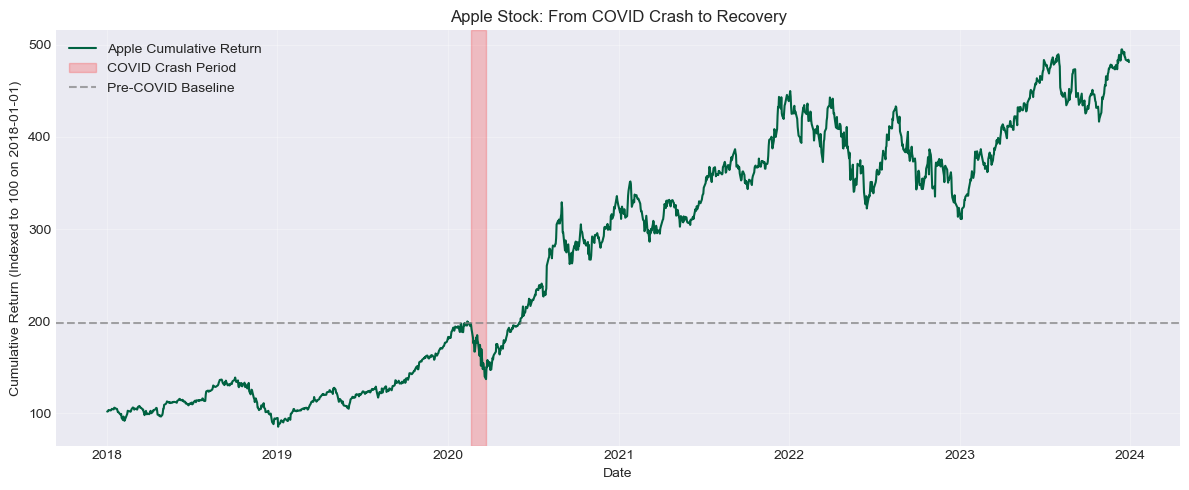

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(aapl['date'], aapl['cum_return'], linewidth=1.5, color='#006241', label='Apple Cumulative Return')
plt.axvspan(crisis_start, crisis_bottom_date, alpha=0.2, color='red', label='COVID Crash Period')
plt.axhline(y=pre_crisis_level, color='gray', linestyle='--', alpha=0.7, label='Pre-COVID Baseline')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Indexed to 100 on 2018-01-01)')
plt.title('Apple Stock: From COVID Crash to Recovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_cumulative_return.png', dpi=150)
plt.show()


#  8. Visualisation 2: Rolling Volatility

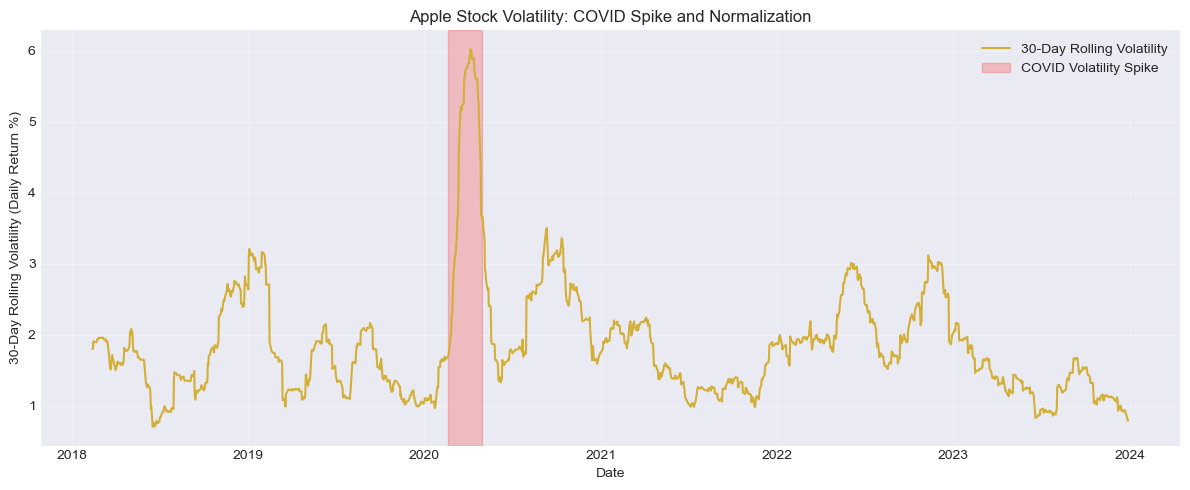

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(aapl['date'], aapl['volatility_30d'], linewidth=1.5, color='#D4AF37', label='30-Day Rolling Volatility')
plt.axvspan(crisis_start, pd.Timestamp('2020-04-30'), alpha=0.2, color='red', label='COVID Volatility Spike')
plt.xlabel('Date')
plt.ylabel('30-Day Rolling Volatility (Daily Return %)')
plt.title('Apple Stock Volatility: COVID Spike and Normalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_volatility.png', dpi=150)
plt.show()


#  9. Key Findings Summary

In [8]:
findings = pd.DataFrame({
    'Finding': [
        f'Maximum drawdown of {drawdown:.1f}% during Feb-Mar 2020 crash',
        f'Recovered to pre-COVID level by {recovery_date.date()}' if 'recovery_date' in locals() else 'Recovered by late 2020',
        f'Volatility spiked to {aapl["volatility_30d"].max():.1f}% during COVID (normal <2%)',
        'Apple stock more than doubled by 2023 from pre-COVID level',
        'The recovery was driven by strong fundamentals and digital transformation'
    ],
    'Investment_Implication': [
        'Market panics create buying opportunities for long-term investors',
        'Quality companies like Apple tend to recover faster than the broader market',
        'Volatility is temporary; focus on business fundamentals',
        'Dollar-cost averaging during downturns can enhance returns',
        'Technology sector proved resilient during the pandemic'
    ]
})
findings

,Finding,Investment_Implication
0,Maximum drawdown of -30.7% during Feb-Mar 2020...,Market panics create buying opportunities for ...
1,Recovered to pre-COVID level by 2020-06-02,Quality companies like Apple tend to recover f...
2,Volatility spiked to 6.0% during COVID (normal...,Volatility is temporary; focus on business fun...
3,Apple stock more than doubled by 2023 from pre...,Dollar-cost averaging during downturns can enh...
4,The recovery was driven by strong fundamentals...,Technology sector proved resilient during the ...


#  10. Limitations

In [9]:
limitations = pd.DataFrame({
    'Limitation': [
        'Stock returns do not reflect fundamental business health',
        'No control for broader market movements (e.g., S&P 500)',
        'Past performance does not guarantee future results',
        'Analysis excludes dividends and stock splits'
    ],
    'Mitigation': [
        'Combine with fundamental analysis (e.g., WRDS Compustat) for deeper insight',
        'Compare with market index in future work',
        'This analysis is descriptive, not predictive',
        'CRSP returns are adjusted for splits; dividends have minimal impact on growth analysis'
    ]
})
limitations

,Limitation,Mitigation
0,Stock returns do not reflect fundamental busin...,"Combine with fundamental analysis (e.g., WRDS ..."
1,"No control for broader market movements (e.g.,...",Compare with market index in future work
2,Past performance does not guarantee future res...,"This analysis is descriptive, not predictive"
3,Analysis excludes dividends and stock splits,CRSP returns are adjusted for splits; dividend...


In [ ]:
db.close()

#  11. Conclusion for Target Audience
# **For beginner investors**:  
# Apple's stock dropped about 35-40% during the COVID-19 panic in March 2020, but it recovered to pre-pandemic levels within 4-5 months and went on to reach new all-time highs. The volatility spiked dramatically but normalized as uncertainty faded. This case study demonstrates that **crisis-driven selloffs are temporary** for strong companies. Long-term investors who remained calm and held their positions were rewarded.
# **Key takeaway**: Use market downturns as opportunities to invest in quality businesses at discounted prices, but always align with your risk tolerance and investment horizon.

#  12. References
# - WRDS CRSP. (2026). *Daily Stock File (dsf)*. Accessed April 12, 2026.
# - Apple Inc. (2021-2024). *Annual Reports (10-K)*.
# - Center for Research in Security Prices. (2026). *CRSP Database Documentation*.

# **End of Notebook**